# Evaluation analysis — confusion matrix, per-class F1, and Grad-CAM

This notebook is designed to run **after** training is complete.
Load your saved checkpoints, then run all cells.

Covers:
1. Per-class accuracy, precision, recall, F1 (sklearn `classification_report`)
2. Confusion matrix heatmap (most-confused artist pairs)
3. Grad-CAM saliency maps — visualise which image regions the model attends to


In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from keras.utils import image_dataset_from_directory
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import tensorflow_addons as tfa

## 1 — Load trained models and collect predictions

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR    = Path("..\wikiart_split")
CKPT_DIR    = Path("Checkpoints")            # folder containing .keras checkpoint files
IMAGE_SIZE  = (384, 384)
BATCH_SIZE  = 16

CONF_MAT_DIR = Path("confusion_matrices")
GRADCAM_DIR = Path("gradcams")

# Map checkpoint filenames to display names
CHECKPOINTS = {
    "EfficientNetV2S": CKPT_DIR / "ckpt_phase2_efficientnetv2s.tf",
    "Xception":        CKPT_DIR / "ckpt_phase2_xception.tf",
    "MyCNN":           CKPT_DIR / "checkpoint_my_cnn",
    # Add DINOv2 if trained:
    "DINOv2":        CKPT_DIR / "ckpt_dino.keras",
}

# ── Load test dataset (shuffle=False — must preserve image order) ─────────────
test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    crop_to_aspect_ratio=True,
    shuffle=False,
    seed=123,
)
class_names = test_ds.class_names
N_CLASSES   = len(class_names)
test_ds     = test_ds.cache().prefetch(tf.data.AUTOTUNE)

# Ground-truth labels (integer class indices)
true_labels = np.concatenate(
    [np.argmax(y.numpy(), axis=1) for _, y in test_ds], axis=0
)
print(f"Test set: {len(true_labels)} images, {N_CLASSES} classes")


Found 2022 files belonging to 23 classes.
Test set: 2022 images, 23 classes


In [4]:
# ── Load models and predict ────────────────────────────────────────────────────
# For DINOv2 you need the feature test dataset instead — see dino_v2_model.ipynb
model_preds = {}    # name -> predicted class indices
model_probs = {}    # name -> softmax probability arrays (for ensemble)
models      = {}    # name -> loaded keras model (needed for Grad-CAM)

for name, ckpt_path in CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f"  SKIPPING {name} — checkpoint not found: {ckpt_path}")
        continue
    print(f"Loading {name} from {ckpt_path}...")
    model = keras.models.load_model(ckpt_path)
    if name == "DINOv2":
        # Caminhos para os teus ficheiros (ajusta se necessário)
        X_test_feats = np.load("dino_features/test_features.npy") # Devem ter shape (N, 768)
        y_test_labels = np.load("dino_features/test_labels.npy")   # Devem ter shape (N, N_CLASSES) ou (N,)

        # Se os teos labels forem índices (0, 1, 2...), converte para o formato esperado (true_labels)
        # Se já forem categóricos (one-hot), usa np.argmax
        if y_test_labels.ndim > 1:
            true_labels = np.argmax(y_test_labels, axis=1)
        else:
            true_labels = y_test_labels
        probs = model.predict(X_test_feats, batch_size=BATCH_SIZE, verbose=0)
    else:
        probs = model.predict(test_ds, verbose=0)
    model_probs[name] = probs
    model_preds[name] = np.argmax(probs, axis=1)
    models[name]      = model
    acc = np.mean(model_preds[name] == true_labels)
    print(f"  {name}: accuracy = {acc:.4f}")


  SKIPPING EfficientNetV2S — checkpoint not found: Checkpoints\ckpt_phase2_efficientnetv2s.tf
  SKIPPING Xception — checkpoint not found: Checkpoints\ckpt_phase2_xception.tf
Loading MyCNN from Checkpoints\checkpoint_my_cnn...
  MyCNN: accuracy = 0.3492
Loading DINOv2 from Checkpoints\ckpt_dino.keras...
  DINOv2: accuracy = 0.8111


## 2 — Per-class classification report

In [5]:
for name, preds in model_preds.items():
    print(f"\n{'='*60}")
    print(f"Classification report — {name}")
    print('='*60)
    print(classification_report(
        true_labels, preds,
        target_names=class_names,
        digits=3,
    ))


Classification report — MyCNN
                       precision    recall  f1-score   support

       Albrecht_Durer      0.410     0.494     0.448        87
      Boris_Kustodiev      0.154     0.206     0.176        68
     Camille_Pissarro      0.403     0.309     0.349        94
        Childe_Hassam      0.245     0.407     0.306        59
         Claude_Monet      0.600     0.170     0.265       141
          Edgar_Degas      0.196     0.169     0.182        65
        Eugene_Boudin      0.268     0.441     0.333        59
         Gustave_Dore      0.490     0.938     0.644        80
           Ilya_Repin      0.400     0.448     0.423        58
      Ivan_Aivazovsky      0.495     0.806     0.613        62
        Ivan_Shishkin      0.278     0.357     0.312        56
  John_Singer_Sargent      0.290     0.349     0.317        83
         Marc_Chagall      0.297     0.333     0.314        81
      Martiros_Saryan      0.167     0.131     0.147        61
     Nicholas_Roerich  

## 3 — Confusion matrix

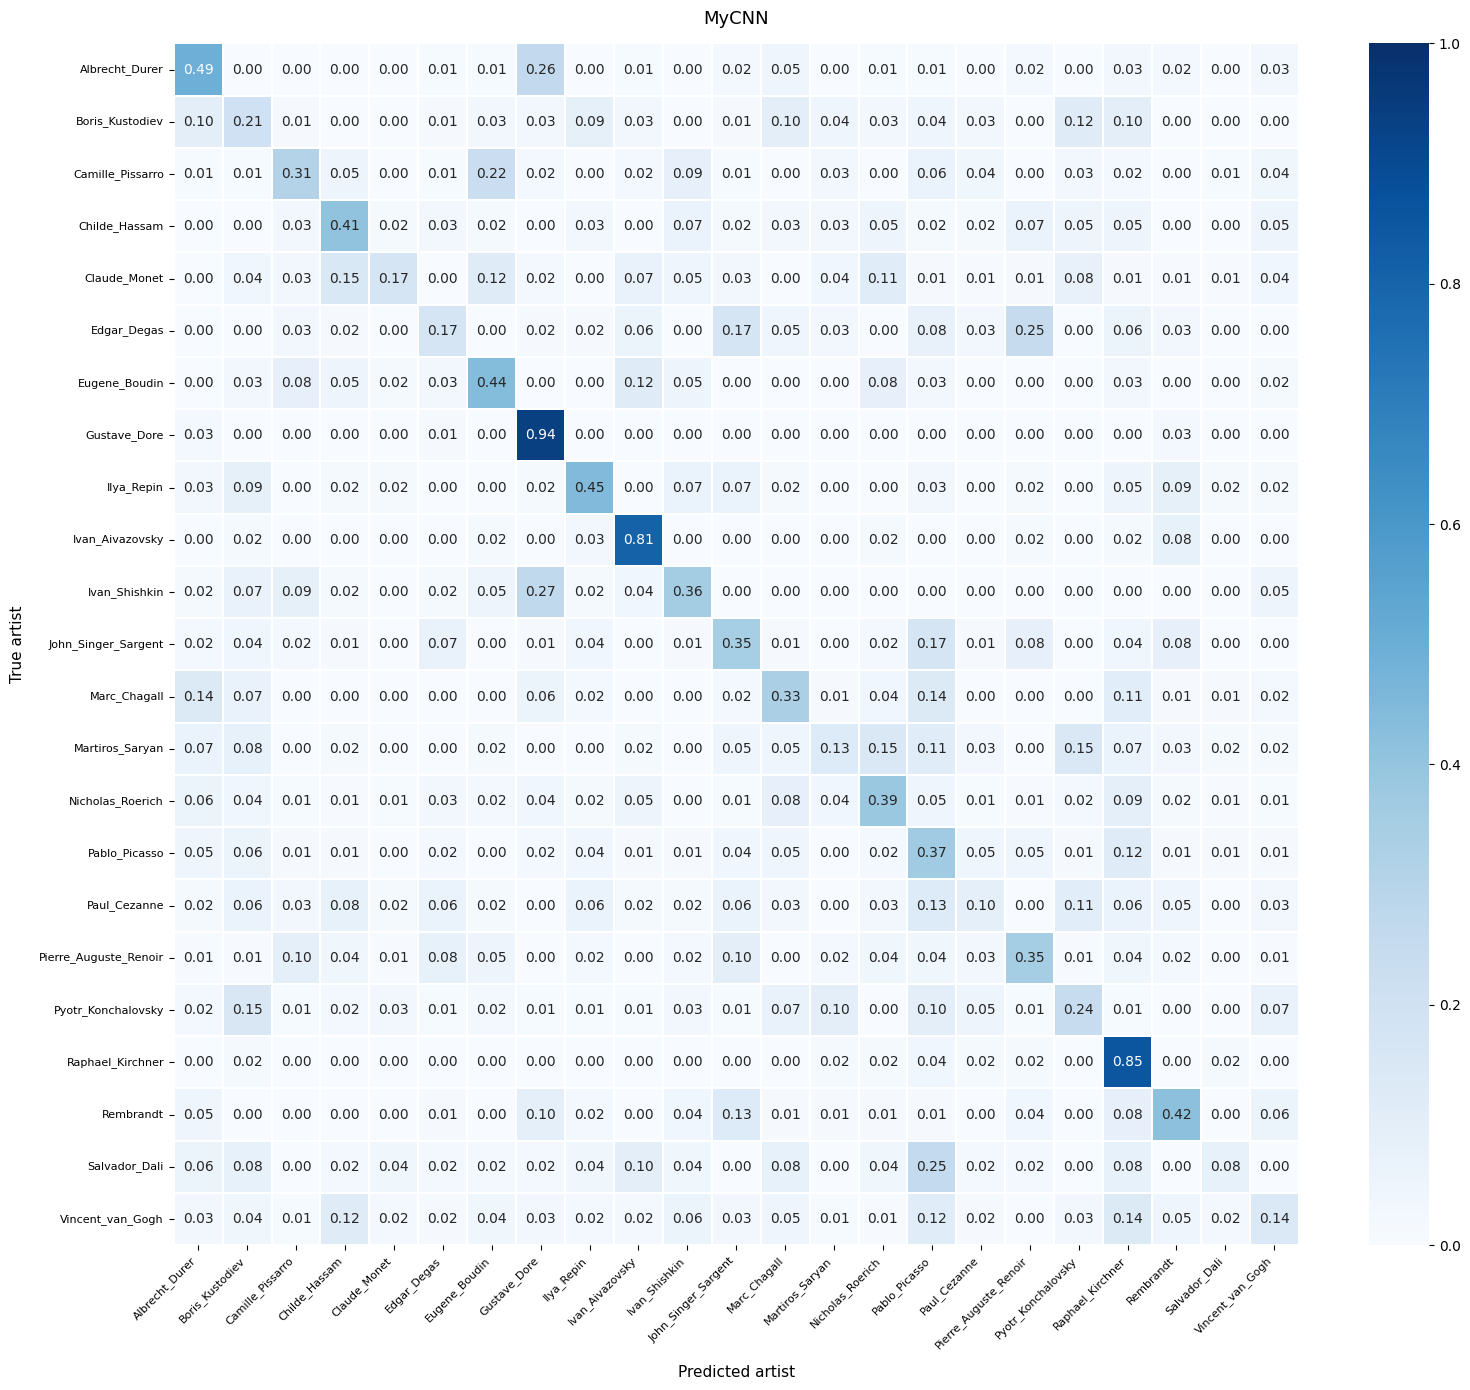

Saved to confusion_matrix_MyCNN.png


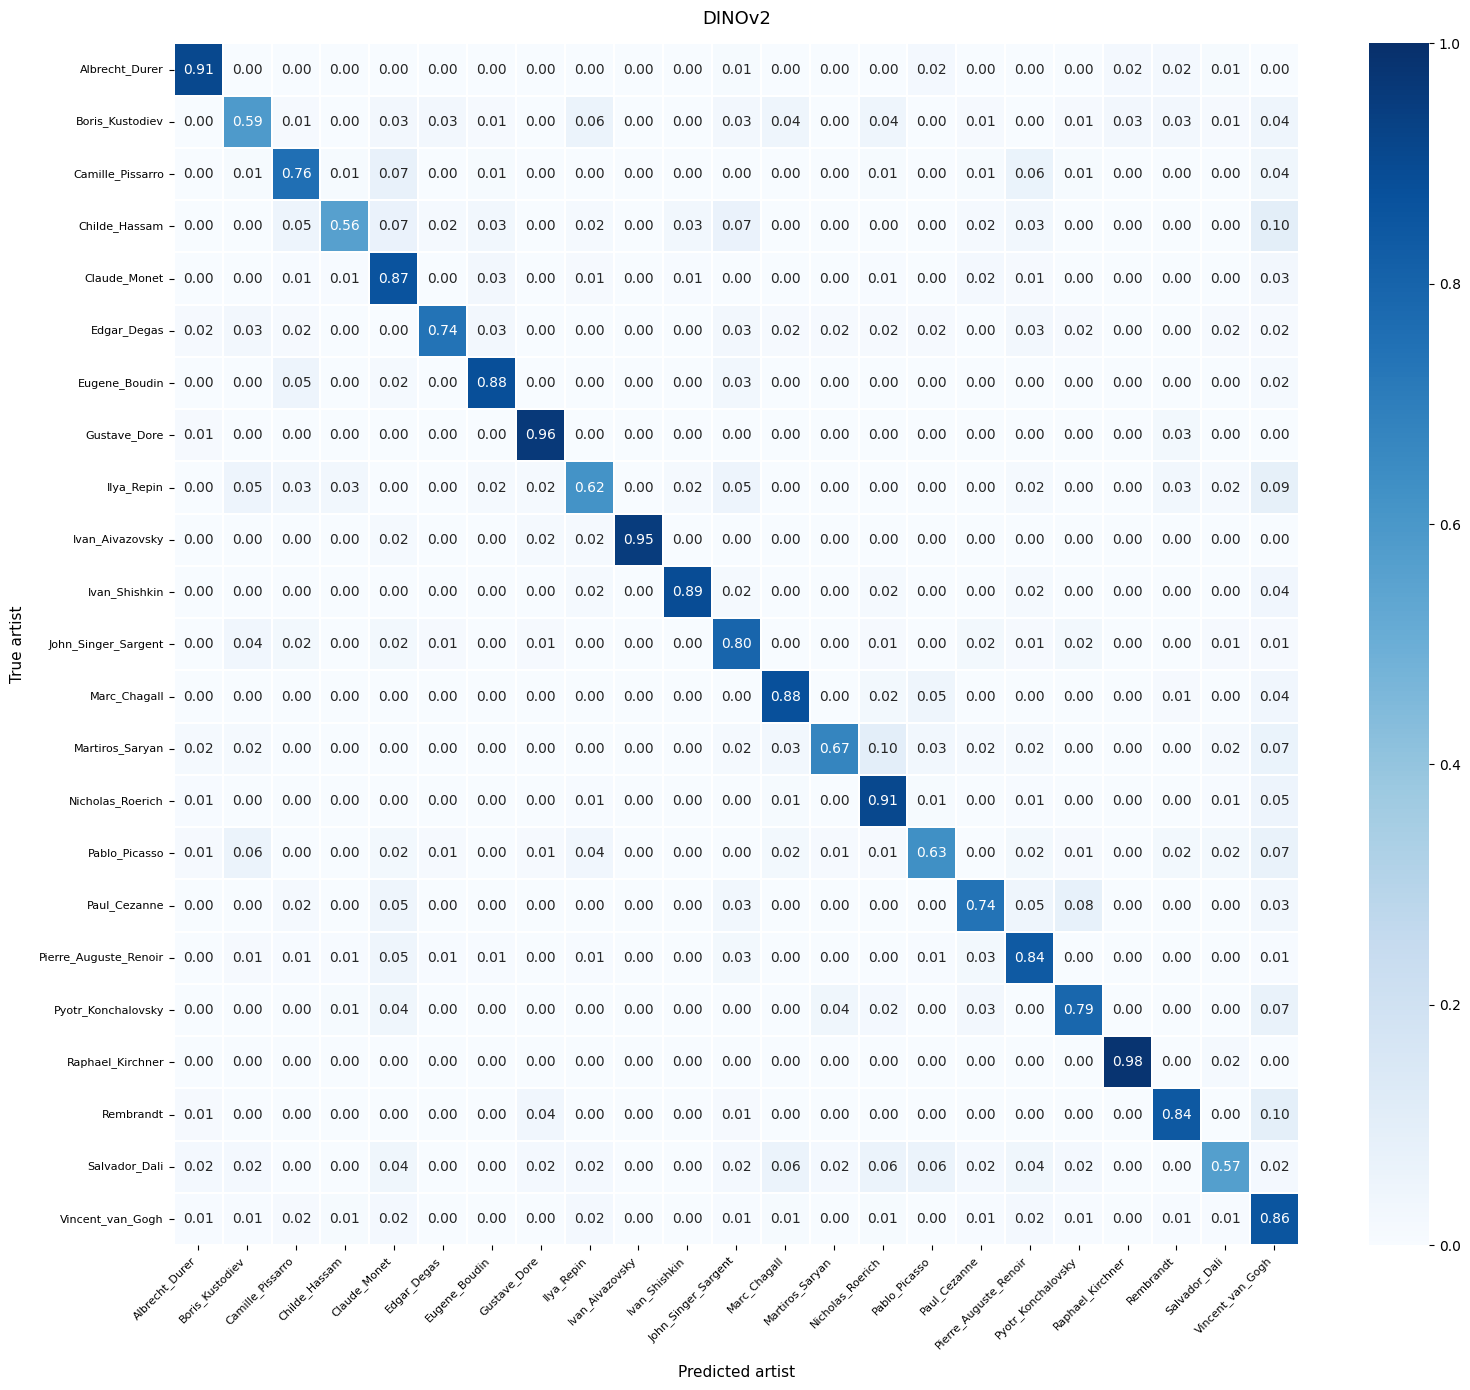

Saved to confusion_matrix_DINOv2.png


In [ ]:
def plot_confusion_matrix(true, pred, class_names, title, figsize=(14, 12)):
    """
    Normalised confusion matrix (row-normalised = recall per class).
    Diagonal = per-class recall. Off-diagonal = what the model confuses it with.
    """
    cm = confusion_matrix(true, pred, normalize="true")

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.3,
        linecolor="white",
        vmin=0, vmax=1,
    )
    ax.set_xlabel("Predicted artist", fontsize=11, labelpad=10)
    ax.set_ylabel("True artist",      fontsize=11, labelpad=10)
    ax.set_title(title, fontsize=13, pad=14)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0,             fontsize=8)
    plt.tight_layout()
    out_path = CONF_MAT_DIR / f"confusion_matrix_{title.replace(' ','_')}.png"
    plt.savefig(out_path,
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {out_path}")


for name, preds in model_preds.items():
    plot_confusion_matrix(true_labels, preds, class_names,
                          title=name, figsize=(16, 14))


In [7]:
# ── Most-confused pairs ───────────────────────────────────────────────────────
# Useful for the report: shows which artists the model systematically conflates.

def most_confused_pairs(true, pred, class_names, top_n=10):
    cm = confusion_matrix(true, pred)
    np.fill_diagonal(cm, 0)   # ignore correct predictions
    pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], class_names[i], class_names[j]))
    pairs.sort(reverse=True)
    print(f"\nTop {top_n} most-confused pairs (true → predicted):")
    print(f"{'Count':>6}  {'True artist':<25} → {'Predicted as'}")
    print("-" * 55)
    for count, true_c, pred_c in pairs[:top_n]:
        print(f"{count:>6}  {true_c:<25} → {pred_c}")

for name, preds in model_preds.items():
    print(f"\n{'='*60}")
    print(f"Most-confused pairs — {name}")
    most_confused_pairs(true_labels, preds, class_names)



Most-confused pairs — MyCNN

Top 10 most-confused pairs (true → predicted):
 Count  True artist               → Predicted as
-------------------------------------------------------
    27  Vincent_van_Gogh          → Raphael_Kirchner
    24  Vincent_van_Gogh          → Childe_Hassam
    23  Vincent_van_Gogh          → Pablo_Picasso
    23  Albrecht_Durer            → Gustave_Dore
    21  Claude_Monet              → Childe_Hassam
    21  Camille_Pissarro          → Eugene_Boudin
    18  Nicholas_Roerich          → Raphael_Kirchner
    17  Claude_Monet              → Eugene_Boudin
    16  Nicholas_Roerich          → Marc_Chagall
    16  Edgar_Degas               → Pierre_Auguste_Renoir

Most-confused pairs — DINOv2

Top 10 most-confused pairs (true → predicted):
 Count  True artist               → Predicted as
-------------------------------------------------------
    10  Nicholas_Roerich          → Vincent_van_Gogh
     8  Rembrandt                 → Vincent_van_Gogh
     7  Pyotr_Kon

## 4 — Ensemble evaluation

Average the softmax probabilities from all loaded models.


Ensemble accuracy: 0.8150

                       precision    recall  f1-score   support

       Albrecht_Durer      0.918     0.897     0.907        87
      Boris_Kustodiev      0.677     0.618     0.646        68
     Camille_Pissarro      0.768     0.777     0.772        94
        Childe_Hassam      0.872     0.576     0.694        59
         Claude_Monet      0.779     0.851     0.814       141
          Edgar_Degas      0.889     0.738     0.807        65
        Eugene_Boudin      0.815     0.898     0.855        59
         Gustave_Dore      0.899     1.000     0.947        80
           Ilya_Repin      0.632     0.621     0.626        58
      Ivan_Aivazovsky      0.938     0.984     0.961        62
        Ivan_Shishkin      0.873     0.857     0.865        56
  John_Singer_Sargent      0.710     0.795     0.750        83
         Marc_Chagall      0.855     0.877     0.866        81
      Martiros_Saryan      0.857     0.689     0.764        61
     Nicholas_Roerich      

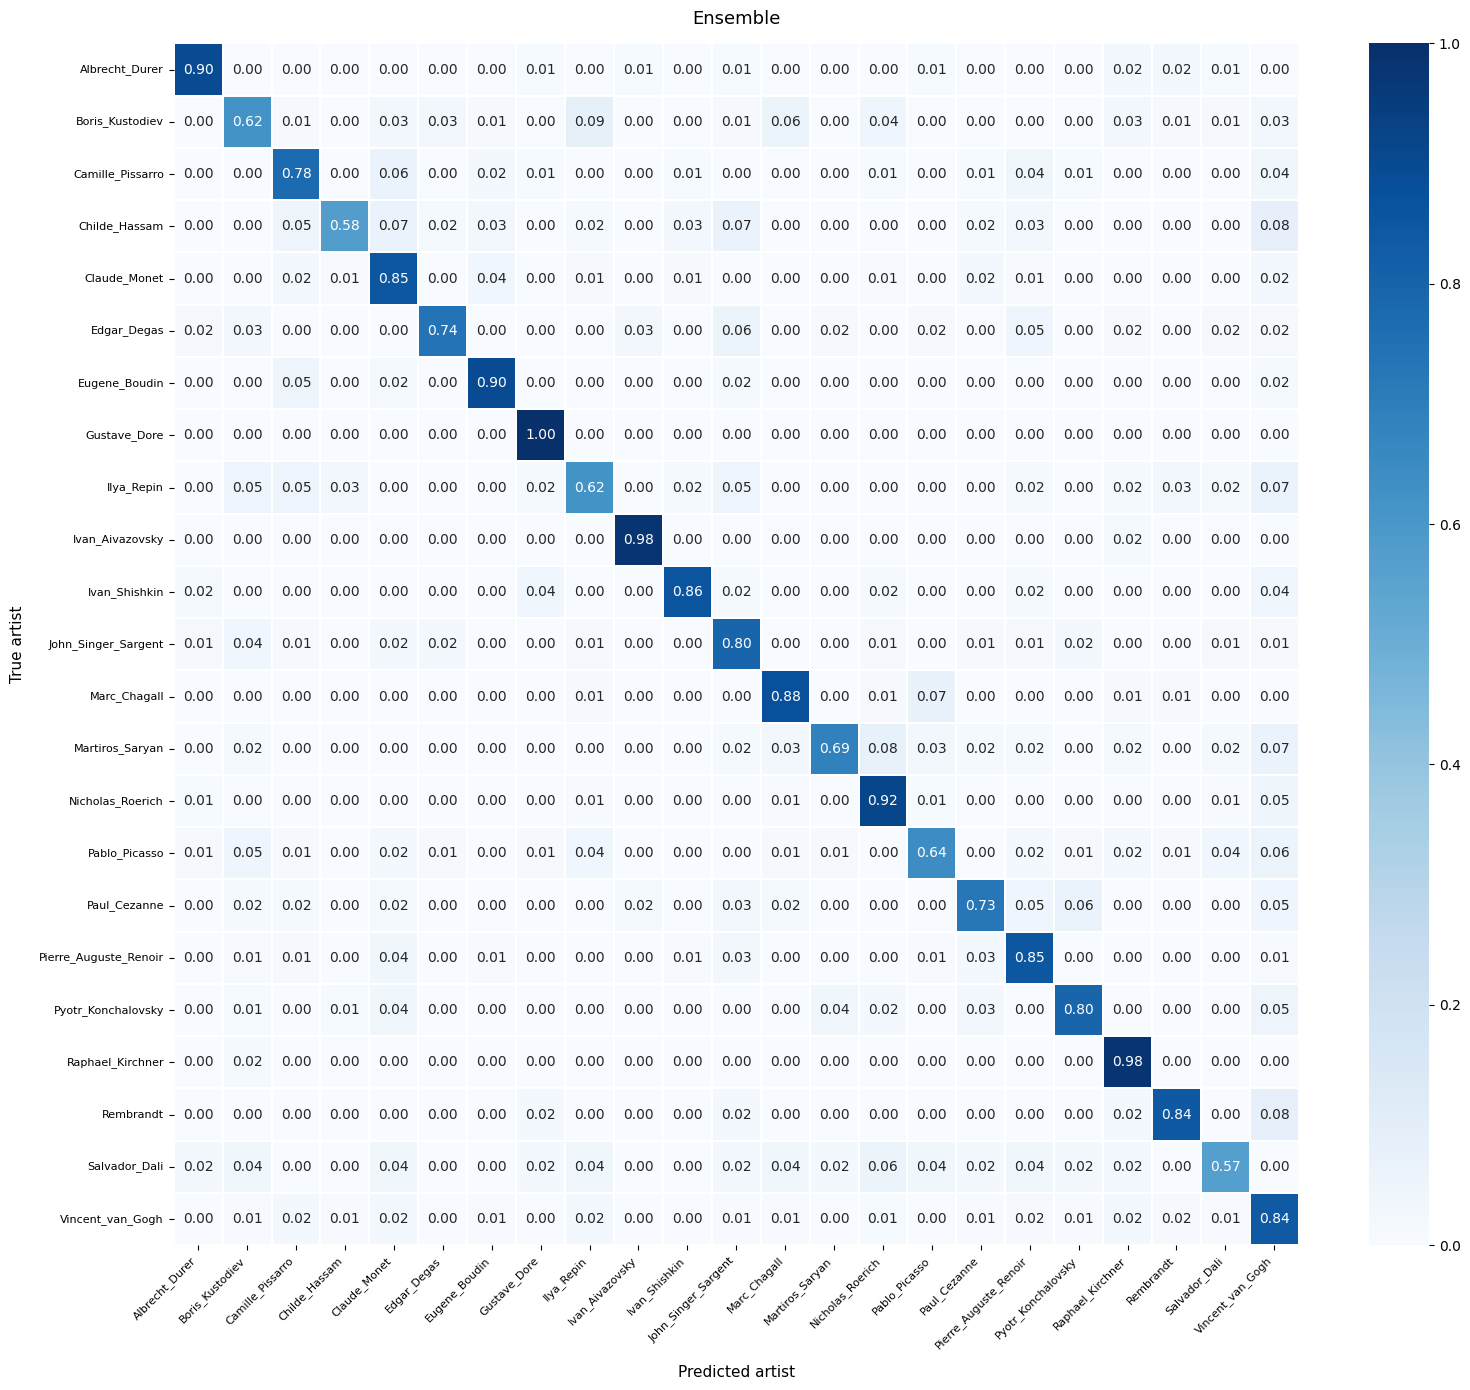

Saved to confusion_matrix_Ensemble.png


In [8]:
if len(model_probs) > 1:
    ensemble_probs = np.mean(list(model_probs.values()), axis=0)
    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    ens_acc = np.mean(ensemble_preds == true_labels)
    print(f"Ensemble accuracy: {ens_acc:.4f}")
    print()
    print(classification_report(true_labels, ensemble_preds,
                                 target_names=class_names, digits=3))
    plot_confusion_matrix(true_labels, ensemble_preds, class_names,
                          title="Ensemble", figsize=(16, 14))
else:
    print("Only one model loaded — skipping ensemble.")


## 5 — Grad-CAM saliency maps

Grad-CAM answers: *which spatial regions of a painting most influenced the prediction?*

It computes the gradient of the predicted class score with respect to the
last convolutional feature map. Regions with strong positive gradients are
highlighted — these are the areas the model "looked at" most.

**For the report:** show examples where Grad-CAM attends to brushstroke
texture (good) vs. the primary subject like a boat or tree (bad — subject bias).

Works with: MyCNN, EfficientNetV2S, Xception. Does NOT apply to DINOv2
(which is a ViT, not a CNN — attention rollout maps are used instead).


In [21]:
def get_last_conv_layer(model):
    # 1. Se for o teu MyCNN, o conv está dentro do último ResidualBlock
    if hasattr(model, 'blocks') and len(model.blocks) > 0:
        last_block = model.blocks[-1]
        if hasattr(last_block, 'conv'):
            return last_block.conv

    # 2. Se for um modelo standard (EfficientNet, Xception), 
    # procuramos na lista de camadas normal
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer
        # Alguns modelos guardam convs dentro de sub-camadas (ex: ResNet do Keras)
        if hasattr(layer, 'layers'):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return sub_layer

    raise ValueError(f"Não foi possível encontrar a camada Conv2D em {model.name}")





def make_gradcam_heatmap(img_array, model, last_conv_layer):
    # --- CASO ESPECIAL: MyCNN (Subclassed) ---
    if hasattr(model, 'blocks'):
        with tf.GradientTape() as tape:
            # Replicamos o 'call' do modelo manualmente para seguir o gradiente
            x = model.rescaling(img_array)
            
            target_conv_output = None
            for block in model.blocks:
                # Lógica interna do ResidualBlock
                skip = block.shortcut(x)
                conv_out = block.conv(x)
                
                # Guardamos o output se for a camada que queremos visualizar
                if block.conv is last_conv_layer:
                    target_conv_output = conv_out
                
                x = block.bn(conv_out, training=False)
                x = block.actv(x)
                x = block.add([x, skip])
            
            x = model.gap(x)
            for layer in model.dense_layers:
                x = layer(x, training=False) if isinstance(layer, tf.keras.layers.Dropout) else layer(x)
            preds = model.classifier(x)
            
            top_pred_index = tf.argmax(preds[0])
            top_class_channel = preds[:, top_pred_index]

        # Calculamos os gradientes em relação ao output da conv que guardámos
        grads = tape.gradient(top_class_channel, target_conv_output)
        conv_outputs = target_conv_output

    # --- CASO PADRÃO: EfficientNet, Xception (Functional/Sequential) ---
    else:
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[last_conv_layer.output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outputs, preds = grad_model(img_array, training=False)
            top_pred_index = tf.argmax(preds[0])
            top_class_channel = preds[:, top_pred_index]
        
        grads = tape.gradient(top_class_channel, conv_outputs)

    # --- PROCESSAMENTO COMUM DO HEATMAP ---
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    # Multiplicamos cada canal pelo seu peso de importância
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalização ReLU e escala 0-1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()




def overlay_gradcam(img_array, heatmap, alpha=0.4):
    """Resize heatmap to image size and overlay as a colourmap."""
    import cv2  # pip install opencv-python
    h, w = img_array.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    jet             = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    jet_rgb         = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    overlay         = (1 - alpha) * img_array.astype(float) + alpha * jet_rgb
    return np.clip(overlay, 0, 255).astype(np.uint8)



Generating Grad-CAM grid for MyCNN...
Using conv layer: <keras.layers.convolutional.conv2d.Conv2D object at 0x0000019EB0A5C8E0>


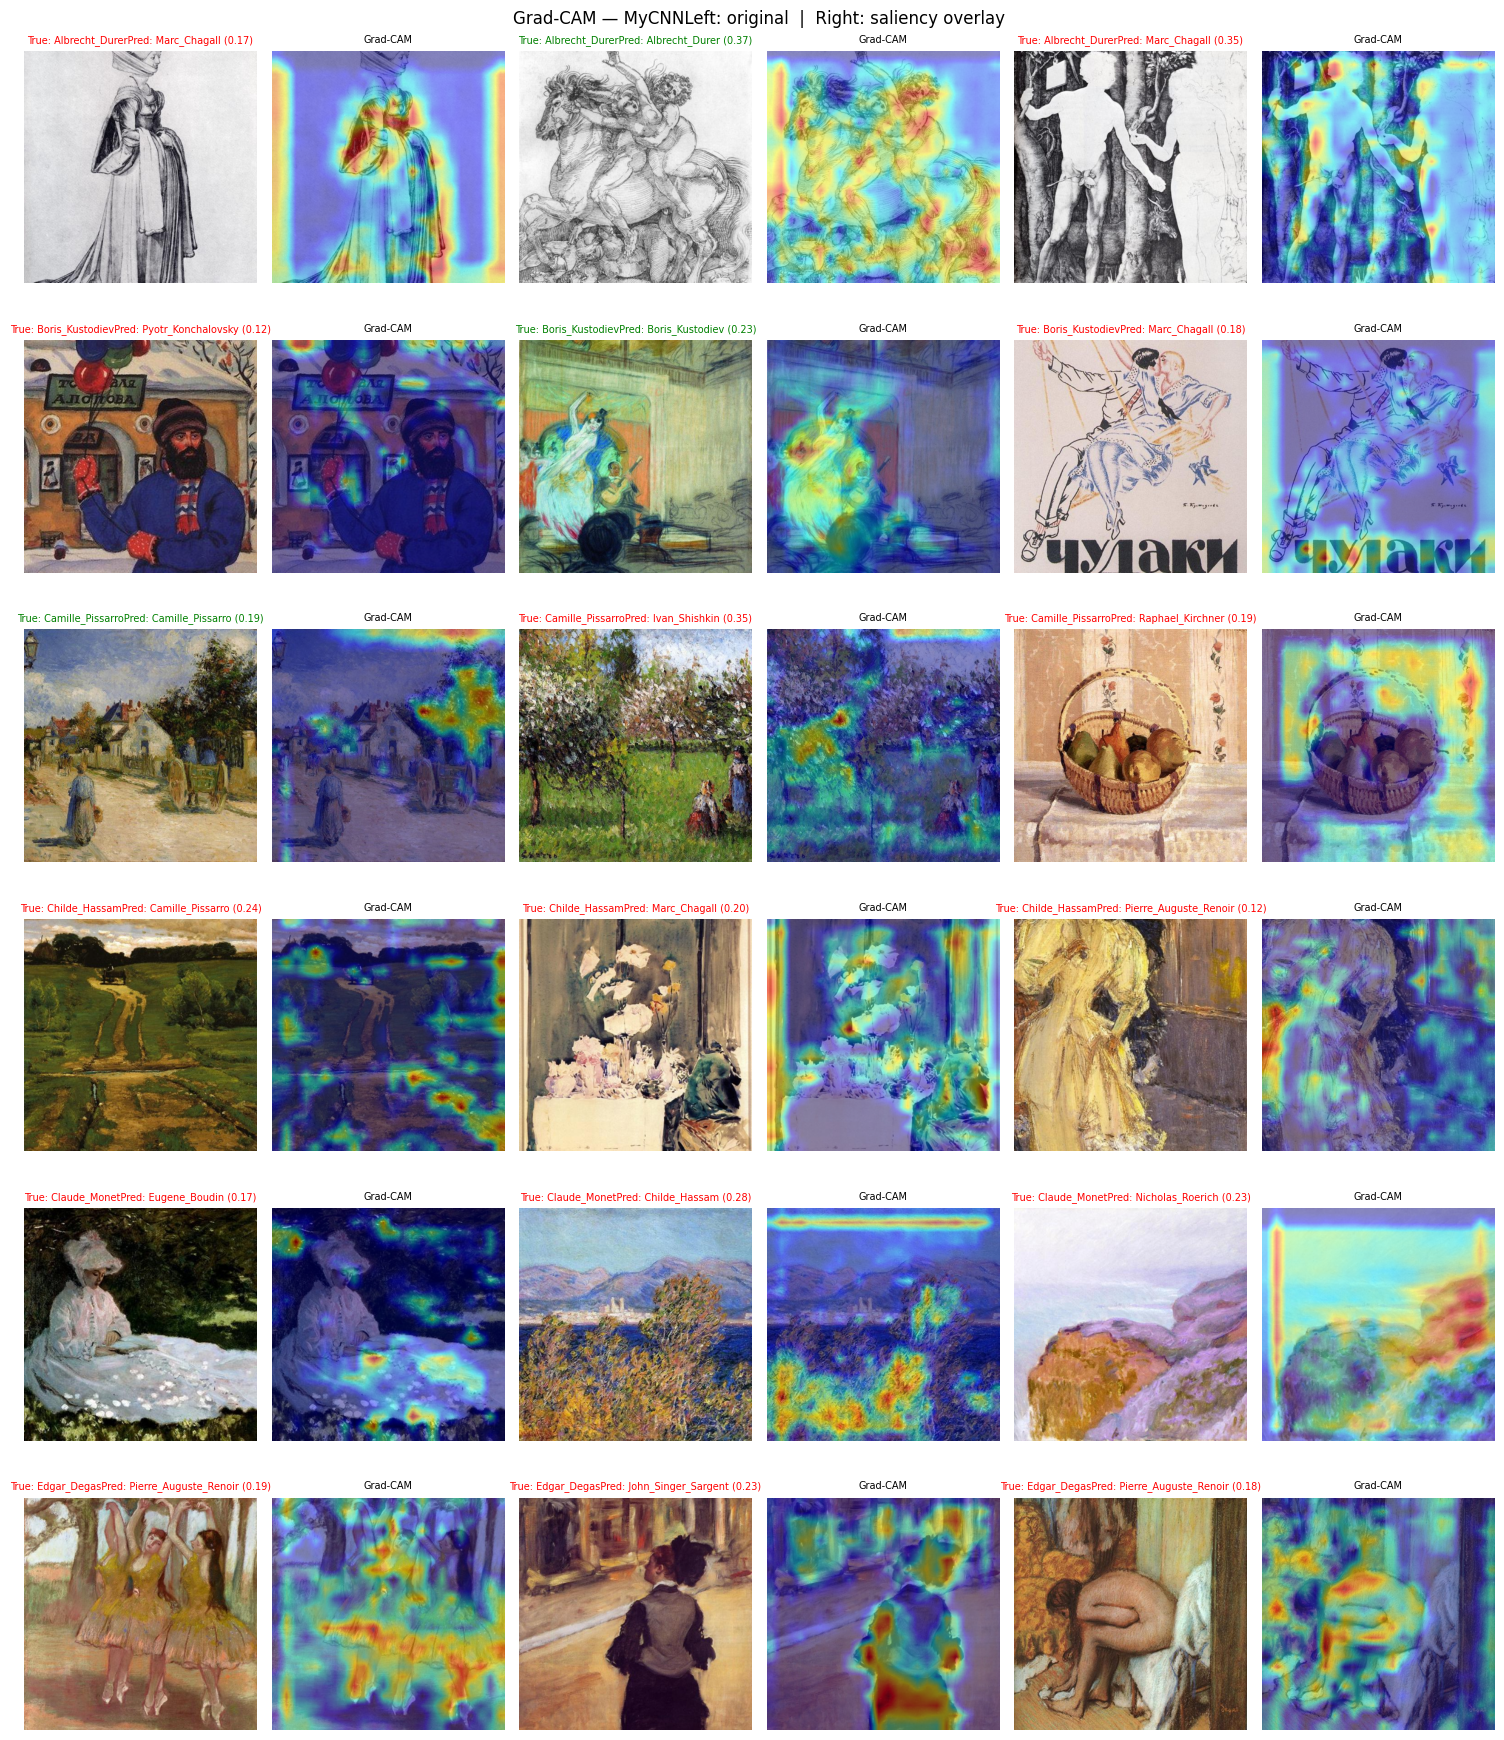

Saved to gradcam_MyCNN.png
Skipping Grad-CAM for DINOv2 (ViT — use attention rollout instead)


In [ ]:
def visualise_gradcam_grid(model, model_name, class_names, data_dir,
                           n_artists=6, n_per_artist=3, image_size=(384, 384)):
    """
    Show Grad-CAM overlays for n_per_artist paintings from n_artists.
    Selects artists with highest error rate first — most informative for the report.
    """
    import cv2
    from PIL import Image as PILImage

    # Find the last conv layer for this model
    try:
        last_conv = get_last_conv_layer(model)
        print(f"Using conv layer: {last_conv}")
    except ValueError as e:
        print(f"Skipping Grad-CAM for {model_name}: {e}")
        return

    train_dir = data_dir / "test"
    artists   = [d.name for d in sorted(train_dir.iterdir()) if d.is_dir()][:n_artists]
    img_exts  = {".jpg", ".jpeg", ".png"}

    fig, axes = plt.subplots(
        n_artists, n_per_artist * 2,
        figsize=(n_per_artist * 5, n_artists * 3)
    )
    fig.suptitle(f"Grad-CAM — {model_name}"
                 f"Left: original  |  Right: saliency overlay", fontsize=12)

    for row, artist in enumerate(artists):
        artist_dir = train_dir / artist
        imgs = [p for p in artist_dir.iterdir()
                if p.suffix.lower() in img_exts][:n_per_artist]

        for col, img_path in enumerate(imgs):
            # Load and preprocess
            img_pil  = PILImage.open(img_path).convert("RGB")
            img_pil  = img_pil.resize((image_size[1], image_size[0]))
            img_np   = np.array(img_pil)
            img_tf   = tf.cast(img_np[tf.newaxis, ...], tf.float32)

            # Predict and get heatmap
            preds      = model(img_tf, training=False).numpy()[0]
            pred_class = np.argmax(preds)
            pred_name  = class_names[pred_class]
            confidence = preds[pred_class]

            heatmap = make_gradcam_heatmap(img_tf, model, last_conv)
            overlay = overlay_gradcam(img_np, heatmap, alpha=0.45)

            # Plot original
            ax_orig = axes[row, col * 2]
            ax_orig.imshow(img_np)
            ax_orig.set_title(f"True: {artist}"
                              f"Pred: {pred_name} ({confidence:.2f})",
                              fontsize=7, color="green" if artist == pred_name else "red")
            ax_orig.axis("off")

            # Plot overlay
            ax_cam = axes[row, col * 2 + 1]
            ax_cam.imshow(overlay)
            ax_cam.set_title("Grad-CAM", fontsize=7)
            ax_cam.axis("off")

    plt.tight_layout()
    out_path = GRADCAM_DIR / f"gradcam_{model_name}.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved to {out_path}")


# ── Run Grad-CAM for all CNN-based models ─────────────────────────────────────
for name, model in models.items():
    if name == "DINOv2":
        print(f"Skipping Grad-CAM for {name} (ViT — use attention rollout instead)")
        continue
    print(f"\nGenerating Grad-CAM grid for {name}...")
    visualise_gradcam_grid(
        model, name, class_names, DATA_DIR,
        n_artists=6, n_per_artist=3
    )


## Tip: reading Grad-CAM outputs for the report

**Good (model is learning style):** activation spreads across the canvas,
highlighting brushstroke texture, paint application, and edge quality.

**Bad (subject bias not fixed):** activation concentrates tightly on the
central subject (a boat, a tree, a face). The model is classifying the
*subject* rather than the *style* — it would fail on a different composition
by the same artist.

If you see the bad pattern predominantly, it means CoarseDropout augmentation
should be increased (higher `p` or larger `max_holes`).
